<a href="https://colab.research.google.com/github/Kiletta/Data-Loading-Importation/blob/main/Kajiado_County_Voter_statistics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Kajiado County Voter Statictics with Interest in Kajiado North Constituency**

## **1.) Import Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
# Statistical modeling
import statsmodels.api as sm
import statsmodels.formula.api as amf
from scipy import stats

## **2.) Data Loading and Initial Exploration**

In [2]:
# Load 034.csv into a DataFrame
print("="*70)
print("Loading data...")
print("="*70)
file_path = '/content/034 - 034.csv.csv'
df = pd.read_csv(file_path)
display(df.head())

Loading data...


,county,constituency,caw,polling_center,polling_station,pstream,date_of_birth,fname,mname,sname,sex,id_passport_no
0,KAJIADO,KAJIADO WEST,EWUASO OoNKIDONG'I,KIBIKO PRI,KIBIKO PRI,1,01/01/1949,DANIEL,KURIA,KANGACHA,Male,1066762
1,KAJIADO,KAJIADO WEST,KEEKONYOKIE,DON BOSCO TRAINING INSTITUTE,DON BOSCO TRAINING INSTITUTE,11,06/04/1983,ZACHEAS KAMAU,NaN,JOSEPH,Male,23566512
2,KAJIADO,KAJIADO WEST,KEEKONYOKIE,DON BOSCO TRAINING INSTITUTE,DON BOSCO TRAINING INSTITUTE,1,01/01/1970,ANNA NJOKI,NaN,KARANJA,Female,9831956
3,KAJIADO,KAJIADO SOUTH,KIMANA,CHRIST THE KING SEC. SCH.,CHRIST THE KING SEC. SCH.,4,01/01/1957,MARY,NJERI,GITAU,Female,370723
4,KAJIADO,KAJIADO WEST,KEEKONYOKIE,DON BOSCO TRAINING INSTITUTE,DON BOSCO TRAINING INSTITUTE,10,02/01/1984,SIMON MUROKI,NaN,NJOROGE,Male,24000227


In [3]:
df.shape
df.head()

,county,constituency,caw,polling_center,polling_station,pstream,date_of_birth,fname,mname,sname,sex,id_passport_no
0,KAJIADO,KAJIADO WEST,EWUASO OoNKIDONG'I,KIBIKO PRI,KIBIKO PRI,1,01/01/1949,DANIEL,KURIA,KANGACHA,Male,1066762
1,KAJIADO,KAJIADO WEST,KEEKONYOKIE,DON BOSCO TRAINING INSTITUTE,DON BOSCO TRAINING INSTITUTE,11,06/04/1983,ZACHEAS KAMAU,NaN,JOSEPH,Male,23566512
2,KAJIADO,KAJIADO WEST,KEEKONYOKIE,DON BOSCO TRAINING INSTITUTE,DON BOSCO TRAINING INSTITUTE,1,01/01/1970,ANNA NJOKI,NaN,KARANJA,Female,9831956
3,KAJIADO,KAJIADO SOUTH,KIMANA,CHRIST THE KING SEC. SCH.,CHRIST THE KING SEC. SCH.,4,01/01/1957,MARY,NJERI,GITAU,Female,370723
4,KAJIADO,KAJIADO WEST,KEEKONYOKIE,DON BOSCO TRAINING INSTITUTE,DON BOSCO TRAINING INSTITUTE,10,02/01/1984,SIMON MUROKI,NaN,NJOROGE,Male,24000227


#### **Document Initial Structure**

In [4]:
print('='*70)
print('DataFrame Info:')
print('='*70)
df.info()

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 463273 entries, 0 to 463272
Data columns (total 12 columns):
 #   Column           Non-Null Count   Dtype 
---  ------           --------------   ----- 
 0   county           463273 non-null  object
 1   constituency     463273 non-null  object
 2   caw              463273 non-null  object
 3   polling_center   463273 non-null  object
 4   polling_station  463273 non-null  object
 5   pstream          463273 non-null  int64 
 6   date_of_birth    463273 non-null  object
 7   fname            463272 non-null  object
 8   mname            348325 non-null  object
 9   sname            463272 non-null  object
 10  sex              463273 non-null  object
 11  id_passport_no   463273 non-null  object
dtypes: int64(1), object(11)
memory usage: 42.4+ MB


## **3.) Exploratory Data Analysis**

### **Date of Birth Analysis**


Top 10 Most Frequent Birth Years:


,count
birth_year,
1988,19712
1987,18292
1986,17421
1992,17161
1989,16841
1990,16754
1994,16319
1993,15823
1984,15256


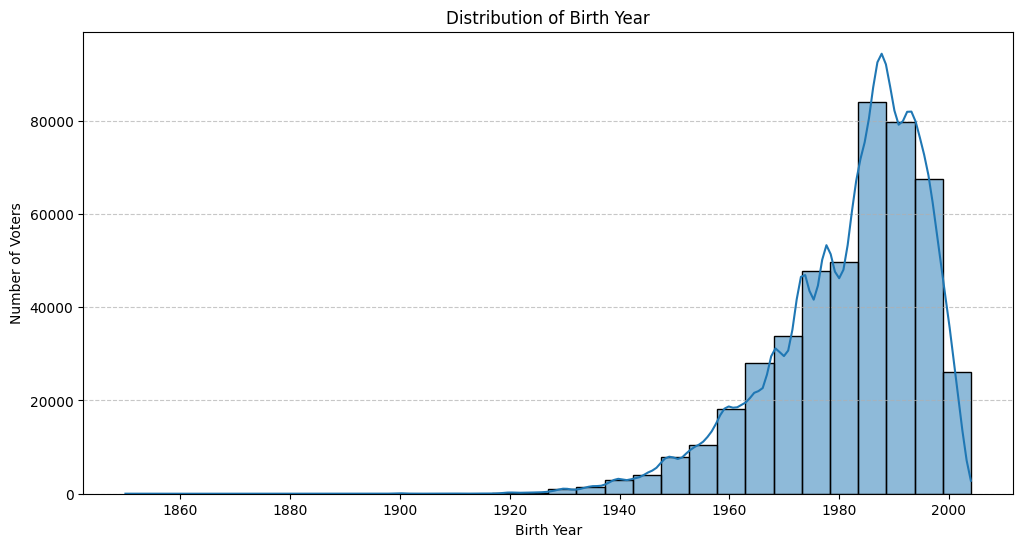


Top 10 Most Frequent Ages:


,count
age,
38,19712
39,18292
40,17421
34,17161
37,16841
36,16754
32,16319
33,15823
42,15256


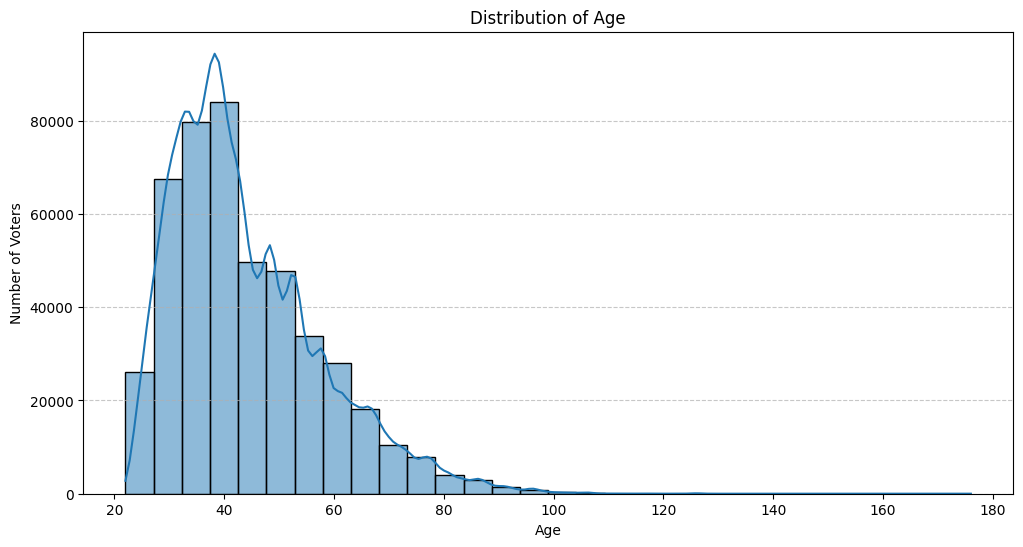

In [5]:
# Convert 'date_of_birth' to datetime objects and extract 'birth_year'
df['date_of_birth'] = pd.to_datetime(df['date_of_birth'], format='%d/%m/%Y', errors='coerce')
df['birth_year'] = df['date_of_birth'].dt.year

# Calculate 'age'
current_year = pd.Timestamp.now().year
df['age'] = current_year - df['birth_year']

# Get top 10 birth years
top_10_birth_years = df['birth_year'].value_counts().nlargest(10)
print('\n'+'='*70)
print('Top 10 Most Frequent Birth Years:')
print('='*70)
display(top_10_birth_years)

# Plot Distribution of Birth Year
plt.figure(figsize=(12, 6))
sns.histplot(df['birth_year'].dropna(), bins=30, kde=True)
plt.title('Distribution of Birth Year')
plt.xlabel('Birth Year')
plt.ylabel('Number of Voters')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Get top 10 ages
top_10_ages = df['age'].value_counts().nlargest(10)
print('\n'+'='*70)
print('Top 10 Most Frequent Ages:')
print('='*70)
display(top_10_ages)

# Plot Distribution of Age
plt.figure(figsize=(12, 6))
sns.histplot(df['age'].dropna(), bins=30, kde=True)
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Number of Voters')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### **Sex Distribution Analysis**
Let's analyze the distribution of voters by sex to understand the gender demographic.


Distribution of Voters by Sex:


,count
sex,
Male,243125
Female,220148



Percentage Distribution of Voters by Sex:


,proportion
sex,
Male,52.479855
Female,47.520145


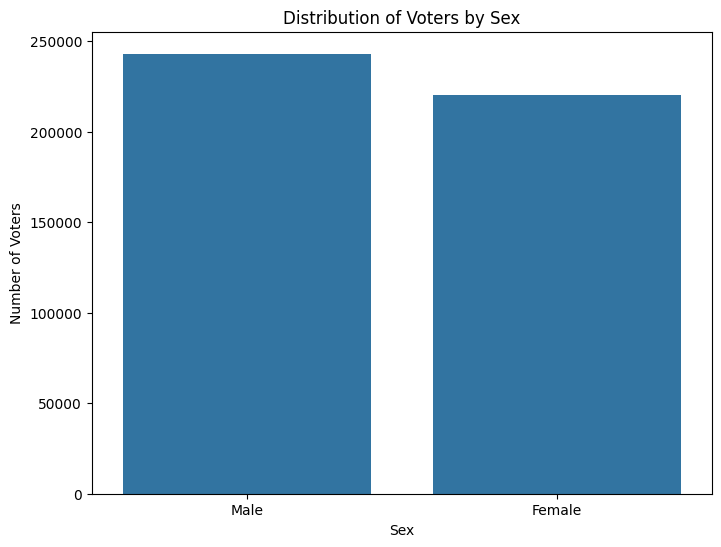

In [6]:
sex_counts = df['sex'].value_counts()
sex_percentages = df['sex'].value_counts(normalize=True) * 100

print('\n'+'='*70)
print('Distribution of Voters by Sex:')
print('='*70)
display(sex_counts)
print('\n'+'='*70)
print('Percentage Distribution of Voters by Sex:')
print('='*70)
display(sex_percentages)

plt.figure(figsize=(8, 6))
sns.barplot(x=sex_counts.index, y=sex_counts.values)
plt.title('Distribution of Voters by Sex')
plt.xlabel('Sex')
plt.ylabel('Number of Voters')
plt.show()

In [7]:
# Convert 'date_of_birth' to datetime objects
df['date_of_birth'] = pd.to_datetime(df['date_of_birth'], format='%d/%m/%Y', errors='coerce')

In [8]:
# Extract 'birth_year'
df['birth_year'] = df['date_of_birth'].dt.year

#### **Distribution of Birth Year**
Let's visualize the distribution of birth years to understand the age demographic of the registered voters.

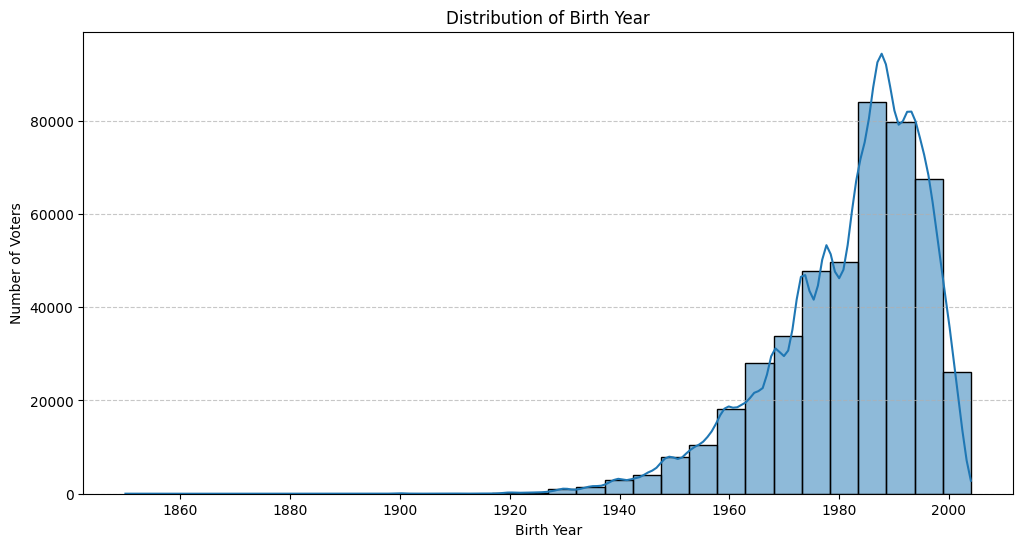

In [9]:
plt.figure(figsize=(12, 6))
sns.histplot(df['birth_year'].dropna(), bins=30, kde=True)
plt.title('Distribution of Birth Year')
plt.xlabel('Birth Year')
plt.ylabel('Number of Voters')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#### **Age Distribution**
Let's also look at the age distribution of the voters. We will calculate the age based on the birth year.

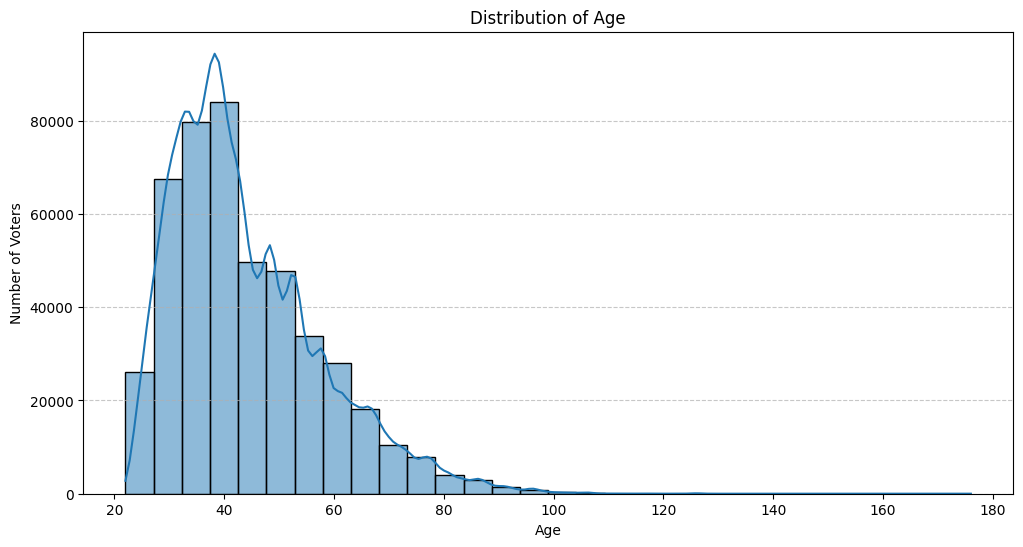

In [10]:
current_year = pd.Timestamp.now().year
df['age'] = current_year - df['birth_year']

plt.figure(figsize=(12, 6))
sns.histplot(df['age'].dropna(), bins=30, kde=True)
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Number of Voters')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [11]:
# @title step_artifacts
num_fig = "2" # @param {type:"string"}
step = 'DataExploration'  # @param ["DataLoading", "DataExploration", "DataCleaning", "DataWrangling", "DataVisualization", "DataSplitting", "ModelDevelopment", "ModelOptimization", "ModelEvaluation", "Summary"] {type:"string"}
# upload_plt_to_gcs(num_fig, step, fig) # Assuming fig is defined from the previous plot

### **County Assembly Ward (CAW) Distribution Analysis**
Let's analyze the distribution of voters across different County Assembly Wards.


Distribution of Voters by CAW:


,count
caw,
KITENGELA,38746
OLOOSIRKON/SHOLINKE,33748
KEEKONYOKIE,33307
NKAIMURUNYA,33207
OLKERI,31549
ONGATA RONGAI,27576
NGONG,22738
KAPUTIEI NORTH,21660
OLOOLUA,19810



Percentage Distribution of Voters by CAW:


,proportion
caw,
KITENGELA,8.363535
OLOOSIRKON/SHOLINKE,7.284690
KEEKONYOKIE,7.189497
NKAIMURUNYA,7.167912
OLKERI,6.810023
ONGATA RONGAI,5.952430
NGONG,4.908121
KAPUTIEI NORTH,4.675429
OLOOLUA,4.276096


/tmp/ipykernel_8548/1403426336.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=caw_counts.index, y=caw_counts.values, palette='plasma')


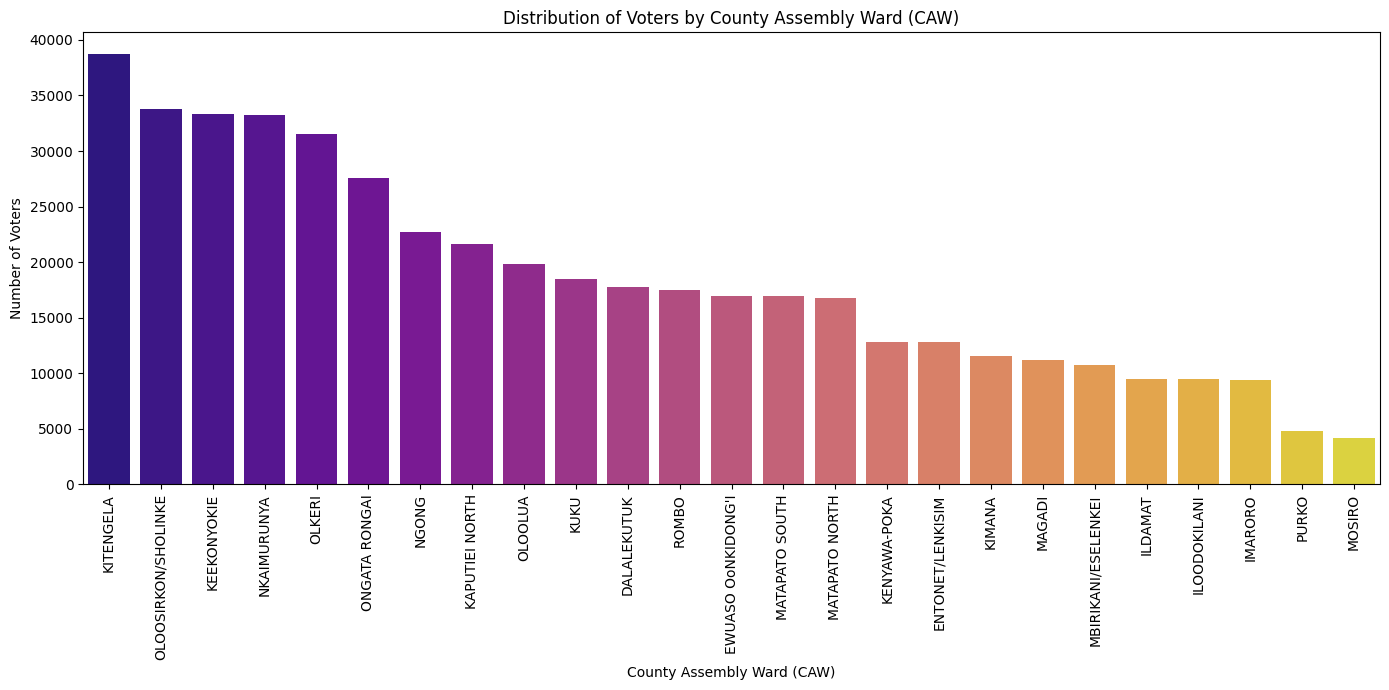

In [12]:
caw_counts = df['caw'].value_counts()
caw_percentages = df['caw'].value_counts(normalize=True) * 100

print('\n'+'='*70)
print('Distribution of Voters by CAW:')
print('='*70)
display(caw_counts)
print('\n'+'='*70)
print('Percentage Distribution of Voters by CAW:')
print('='*70)
display(caw_percentages)

plt.figure(figsize=(14, 7))
sns.barplot(x=caw_counts.index, y=caw_counts.values, palette='plasma')
plt.title('Distribution of Voters by County Assembly Ward (CAW)')
plt.xlabel('County Assembly Ward (CAW)')
plt.ylabel('Number of Voters')
plt.xticks(rotation=90, ha='center')
plt.tight_layout()
plt.show()

In [13]:
# @title step_artifacts
num_fig = "5" # @param {type:"string"}
step = 'DataExploration'  # @param ["DataLoading", "DataExploration", "DataCleaning", "DataWrangling", "DataVisualization", "DataSplitting", "ModelDevelopment", "ModelOptimization", "ModelEvaluation", "Summary"] {type:"string"}
# upload_plt_to_gcs(num_fig, step, fig) # Assuming fig is defined from the previous plot

### **Sex Distribution by County Assembly Ward (CAW)**
Let's analyze the distribution of voters by sex within each County Assembly Ward.


Sex Distribution by CAW (Counts):


sex,Female,Male
caw,,
DALALEKUTUK,8411,9323
ENTONET/LENKISIM,6624,6151
EWUASO OoNKIDONG'I,8213,8759
ILDAMAT,4309,5226
ILOODOKILANI,4567,4909



Sex Distribution by CAW (Percentages):


sex,Female,Male
caw,,
DALALEKUTUK,47.428668,52.571332
ENTONET/LENKISIM,51.851272,48.148728
EWUASO OoNKIDONG'I,48.391468,51.608532
ILDAMAT,45.191400,54.808600
ILOODOKILANI,48.195441,51.804559


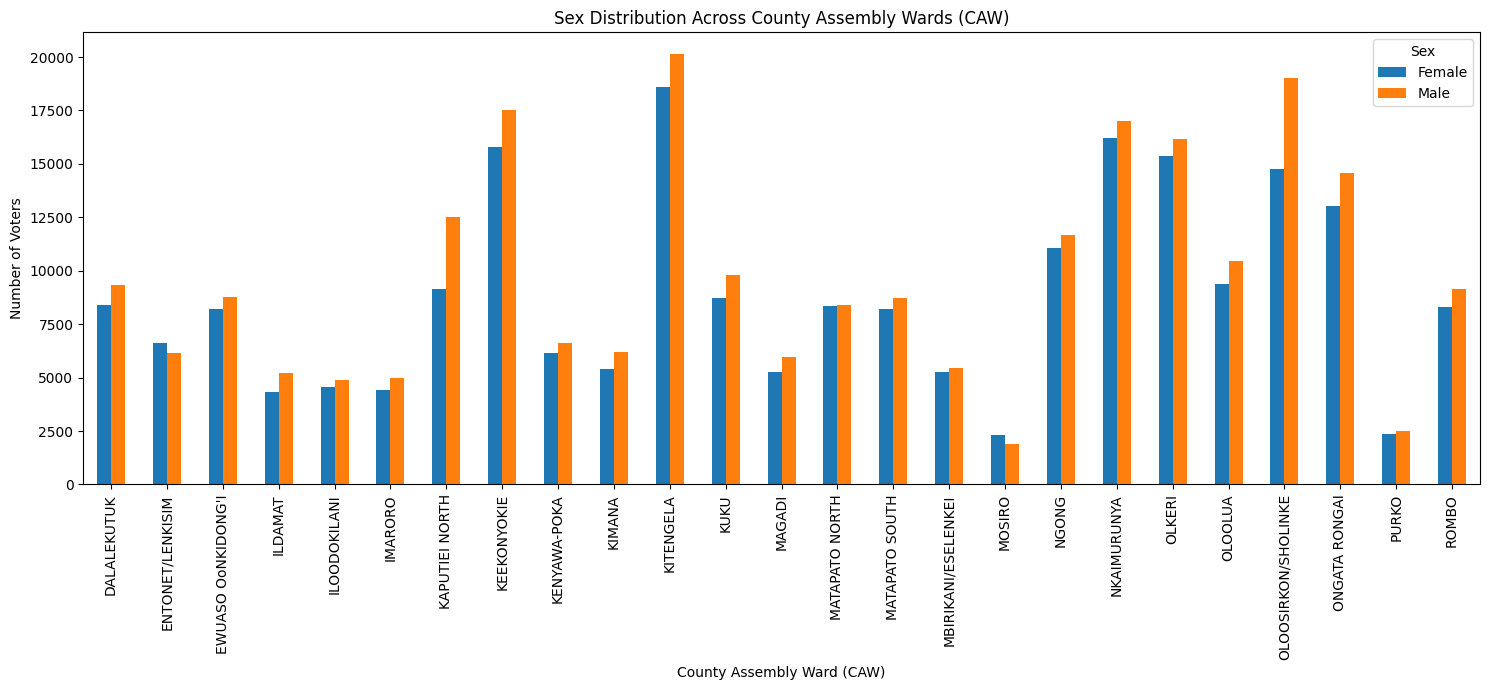

In [14]:
sex_by_caw = df.groupby(['caw', 'sex']).size().unstack(fill_value=0)
sex_by_caw_percentage = sex_by_caw.apply(lambda x: x / x.sum() * 100, axis=1)

print('\n'+'='*70)
print('Sex Distribution by CAW (Counts):')
print('='*70)
display(sex_by_caw.head())

print('\n'+'='*70)
print('Sex Distribution by CAW (Percentages):')
print('='*70)
display(sex_by_caw_percentage.head())

sex_by_caw.plot(kind='bar', figsize=(15, 7), stacked=False)
plt.title('Sex Distribution Across County Assembly Wards (CAW)')
plt.xlabel('County Assembly Ward (CAW)')
plt.ylabel('Number of Voters')
plt.xticks(rotation=90)
plt.legend(title='Sex')
plt.tight_layout()
plt.show()

In [15]:
# @title step_artifacts
num_fig = "6" # @param {type:"string"}
step = 'DataExploration'  # @param ["DataLoading", "DataExploration", "DataCleaning", "DataWrangling", "DataVisualization", "DataSplitting", "ModelDevelopment", "ModelOptimization", "ModelEvaluation", "Summary"] {type:"string"}
# upload_plt_to_gcs(num_fig, step, fig) # Assuming fig is defined from the previous plot

### **Sex Distribution by Constituency**
Now, let's analyze the distribution of voters by sex within each constituency.


Sex Distribution by Constituency (Counts):


sex,Female,Male
constituency,,
KAJIADO CENTRAL,31638,34185
KAJIADO EAST,53049,63287
KAJIADO NORTH,65016,69864
KAJIADO SOUTH,34327,36734
KAJIADO WEST,36118,39055



Sex Distribution by Constituency (Percentages):


sex,Female,Male
constituency,,
KAJIADO CENTRAL,48.065266,51.934734
KAJIADO EAST,45.599814,54.400186
KAJIADO NORTH,48.202847,51.797153
KAJIADO SOUTH,48.306385,51.693615
KAJIADO WEST,48.046506,51.953494


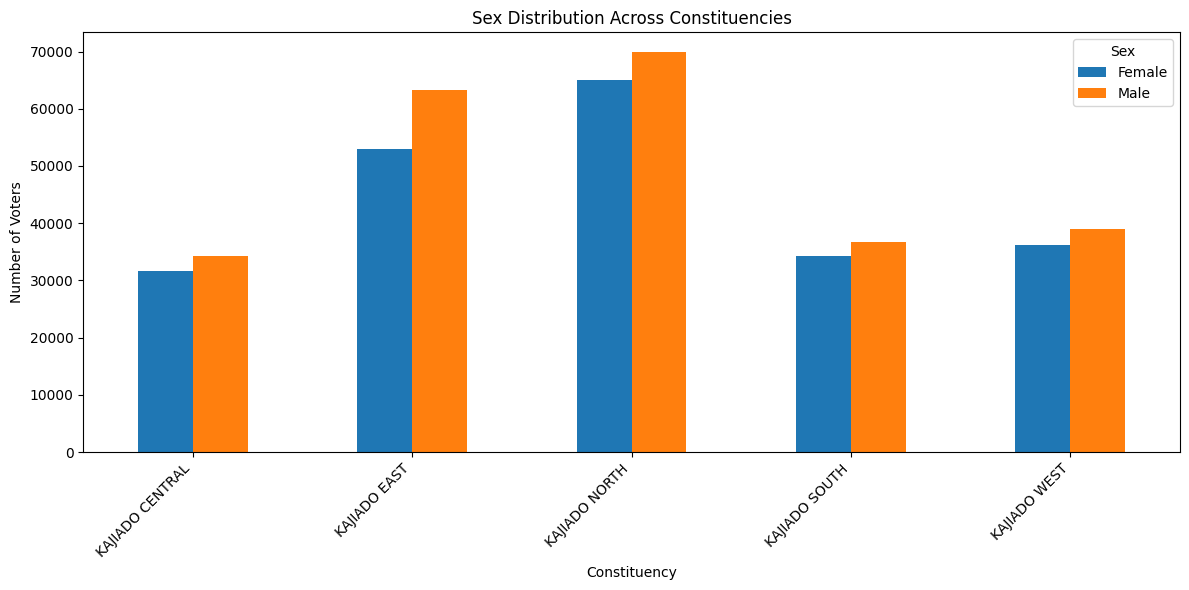

In [16]:
sex_by_constituency = df.groupby(['constituency', 'sex']).size().unstack(fill_value=0)
sex_by_constituency_percentage = sex_by_constituency.apply(lambda x: x / x.sum() * 100, axis=1)

print('\n'+'='*70)
print('Sex Distribution by Constituency (Counts):')
print('='*70)
display(sex_by_constituency.head())

print('\n'+'='*70)
print('Sex Distribution by Constituency (Percentages):')
print('='*70)
display(sex_by_constituency_percentage.head())

sex_by_constituency.plot(kind='bar', figsize=(12, 6), stacked=False)
plt.title('Sex Distribution Across Constituencies')
plt.xlabel('Constituency')
plt.ylabel('Number of Voters')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Sex')
plt.tight_layout()
plt.show()

### **Focusing on Kajiado North Constituency**


In [17]:
df_kajiado_north = df[df['constituency'] == 'KAJIADO NORTH']

print('\n'+'='*70)
print('Data for Kajiado North Constituency:')
print('='*70)
display(df_kajiado_north.head())


Data for Kajiado North Constituency:


,county,constituency,caw,polling_center,polling_station,pstream,date_of_birth,fname,mname,sname,sex,id_passport_no,birth_year,age
7,KAJIADO,KAJIADO NORTH,ONGATA RONGAI,ENDOMOTO CHIEF'S CAMP,ENDOMOTO CHIEF'S CAMP,3,1970-01-01,JOHN,KIAI,MBURU,Male,10849638,1970,56
19,KAJIADO,KAJIADO NORTH,OLKERI,KISERIAN PRI.SCH,KISERIAN PRI.SCH,3,1994-12-15,VALERIA,NYAKARA,OSIEMO,Female,31647174,1994,32
20,KAJIADO,KAJIADO NORTH,NKAIMURUNYA,ONG ATA RONGAI PRI.SCH,ONG ATA RONGAI PRI.SCH,4,1996-03-23,MARTHA,MORAA,OTUORI,Female,32632458,1996,30
34,KAJIADO,KAJIADO NORTH,OLKERI,ST. MARKS? KISERIAN MIXED DAY SECONDARY SCHOOL,ST. MARKS? KISERIAN MIXED DAY SECONDARY SCHOOL,1,1979-01-01,ESTHER,WACUKA,MUKIRI,Female,21966606,1979,47
38,KAJIADO,KAJIADO NORTH,OLKERI,ARAP MOI PRI .SCH,ARAP MOI PRI .SCH,1,1986-08-07,ANDERSON,NaN,NATSE,Male,26524918,1986,40


In [18]:
# @title step_artifacts
num_fig = "9" # @param {type:"string"}
step = 'DataFiltering'  # @param ["DataLoading", "DataExploration", "DataCleaning", "DataWrangling", "DataVisualization", "DataSplitting", "ModelDevelopment", "ModelOptimization", "ModelEvaluation", "Summary"] {type:"string"}
# upload_plt_to_gcs(num_fig, step, fig) # Assuming fig is defined from the previous plot

### **Exploring Unique CAWs and Polling Centers in Kajiado North**

After filtering the dataset to focus on 'Kajiado North' constituency, it's beneficial to understand the unique County Assembly Wards (CAWs) and polling centers present within this specific constituency. This provides insight into the geographical spread and administrative divisions of voter registration in Kajiado North.

In [19]:
unique_caws_kajiado_north = df_kajiado_north['caw'].nunique()
print(f"Number of unique CAWs in Kajiado North: {unique_caws_kajiado_north}")
display(df_kajiado_north['caw'].value_counts())

unique_polling_centers_kajiado_north = df_kajiado_north['polling_center'].nunique()
print(f"\nNumber of unique Polling Centers in Kajiado North: {unique_polling_centers_kajiado_north}")
display(df_kajiado_north['polling_center'].value_counts().head())

Number of unique CAWs in Kajiado North: 5


,count
caw,
NKAIMURUNYA,33207
OLKERI,31549
ONGATA RONGAI,27576
NGONG,22738
OLOOLUA,19810



Number of unique Polling Centers in Kajiado North: 34


,count
polling_center,
ONG ATA RONGAI OPEN AIR MARKET,18065
NAKEEL PRI.SCH,9987
PCEA ENCHORRO EMUNY PRI .SCH,9433
ONGATA ACADEMY-NEW,8965
BULBUL PRI.SCH,8421


In [20]:
# @title step_artifacts
num_fig = "10" # @param {type:"string"}
step = 'DataExploration'  # @param ["DataLoading", "DataExploration", "DataCleaning", "DataWrangling", "DataVisualization", "DataSplitting", "ModelDevelopment", "ModelOptimization", "ModelEvaluation", "Summary"] {type:"string"}
# upload_plt_to_gcs(num_fig, step, fig) # Assuming fig is defined from the previous plot

### **Visualizing Voter Distribution by CAW in Kajiado North**

To further analyze the 'Kajiado North' constituency, we will create a bar chart to visualize the number of voters in each County Assembly Ward (CAW) within this constituency. This will provide a clear overview of how voter registration is distributed across its different administrative units.

/tmp/ipykernel_8548/3594776362.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=caw_counts_kajiado_north.index, y=caw_counts_kajiado_north.values, palette='viridis')


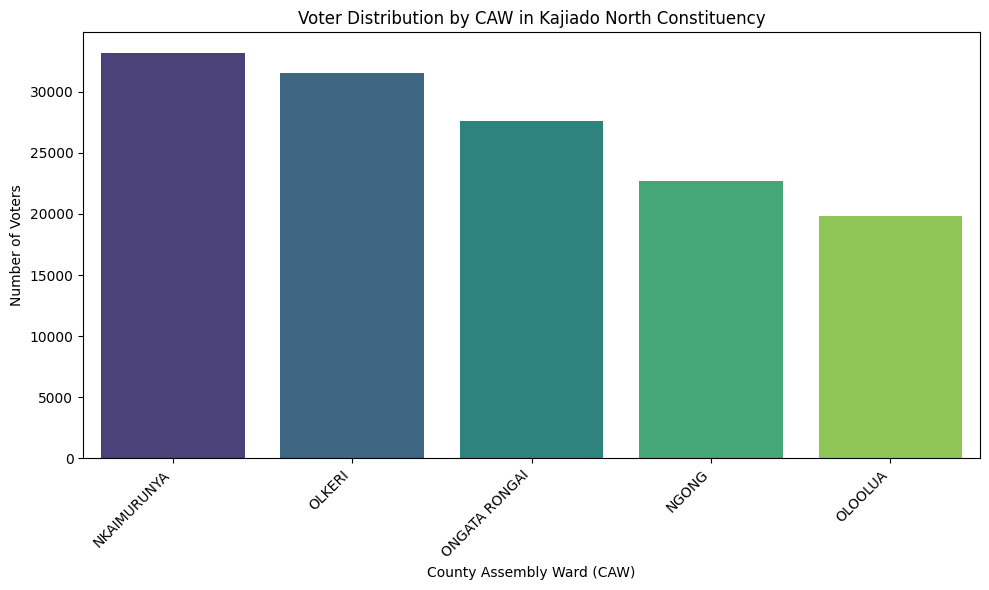

In [21]:
caw_counts_kajiado_north = df_kajiado_north['caw'].value_counts()

plt.figure(figsize=(10, 6))
sns.barplot(x=caw_counts_kajiado_north.index, y=caw_counts_kajiado_north.values, palette='viridis')
plt.title('Voter Distribution by CAW in Kajiado North Constituency')
plt.xlabel('County Assembly Ward (CAW)')
plt.ylabel('Number of Voters')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [22]:
# @title step_artifacts
num_fig = "11" # @param {type:"string"}
step = 'DataVisualization'  # @param ["DataLoading", "DataExploration", "DataCleaning", "DataWrangling", "DataVisualization", "DataSplitting", "ModelDevelopment", "ModelOptimization", "ModelEvaluation", "Summary"] {type:"string"}
# upload_plt_to_gcs(num_fig, step, fig) # Assuming fig is defined from the previous plot

In [23]:
# @title step_artifacts
num_fig = "7" # @param {type:"string"}
step = 'DataExploration'  # @param ["DataLoading", "DataExploration", "DataCleaning", "DataWrangling", "DataVisualization", "DataSplitting", "ModelDevelopment", "ModelOptimization", "ModelEvaluation", "Summary"] {type:"string"}
# upload_plt_to_gcs(num_fig, step, fig) # Assuming fig is defined from the previous plot

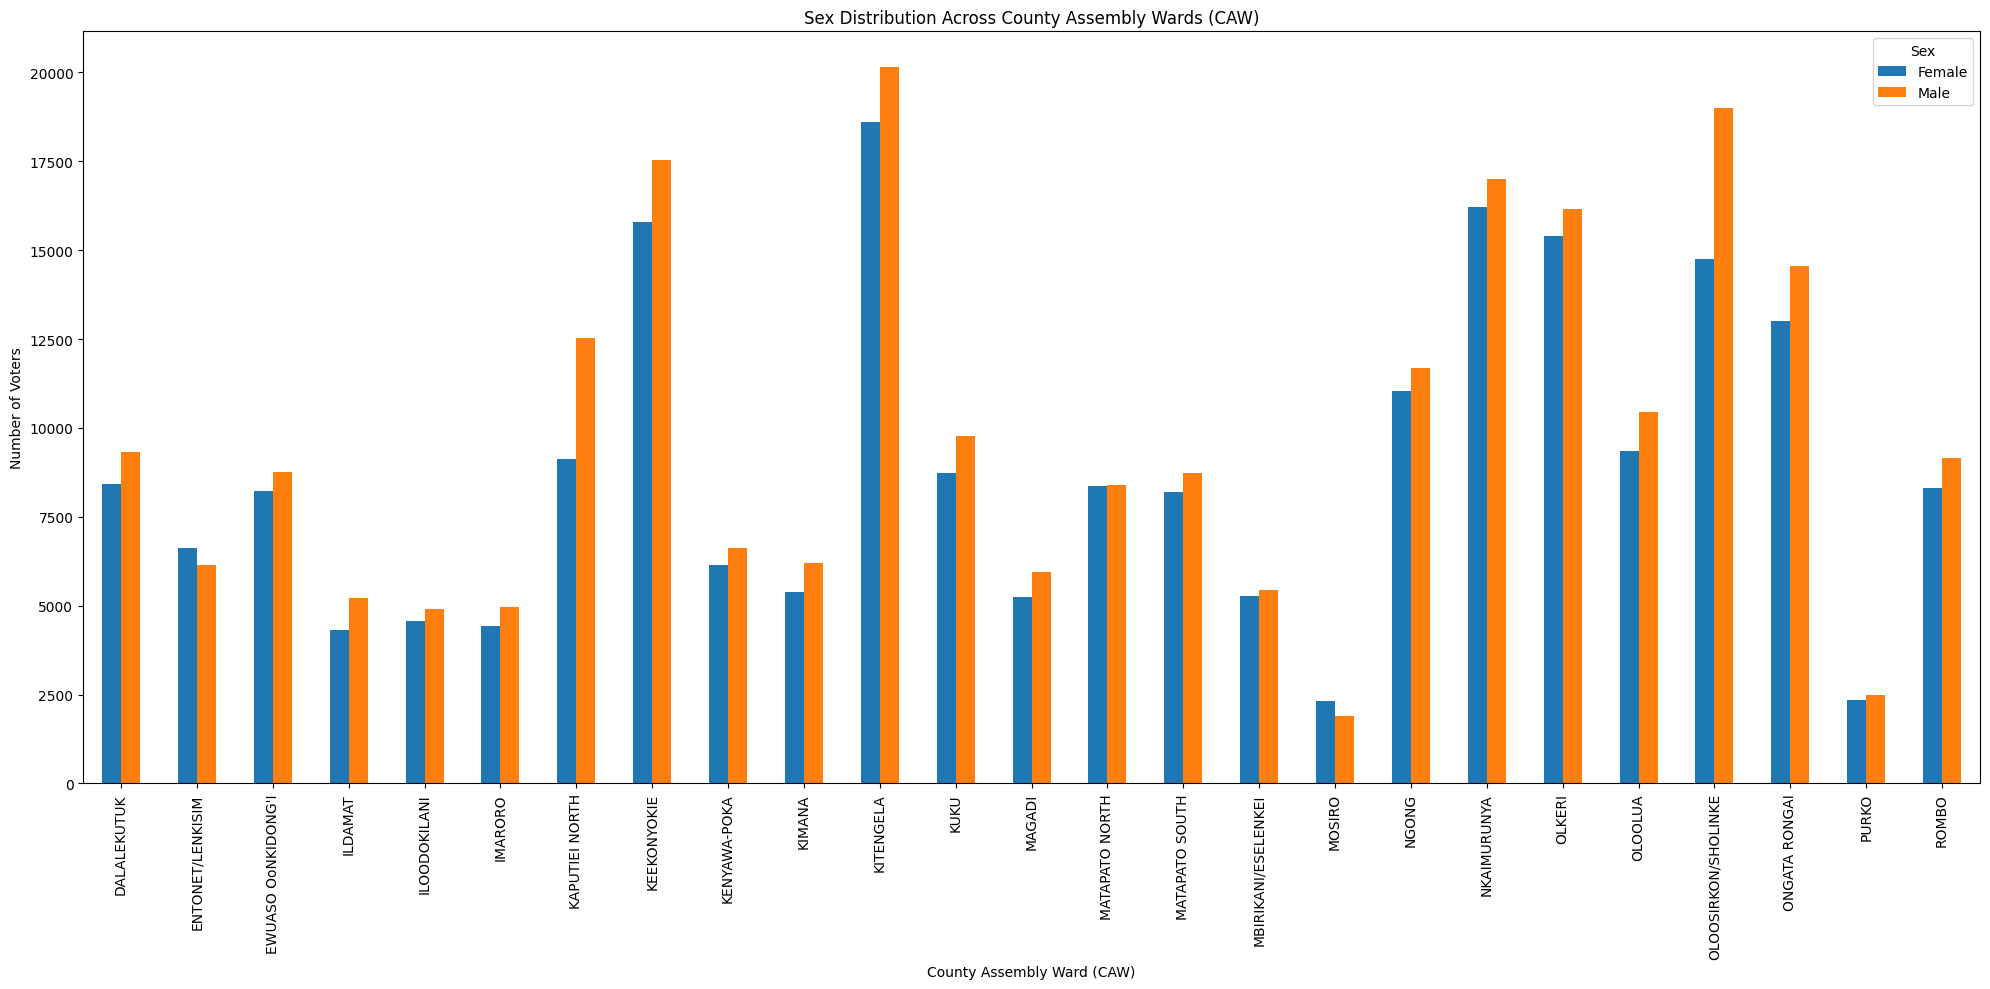

In [24]:
# Bar plot visualizing the sex distribution across all County assembly wards.

sex_by_caw.plot(kind='bar', figsize=(20, 10), stacked=False)
plt.title('Sex Distribution Across County Assembly Wards (CAW)')
plt.xlabel('County Assembly Ward (CAW)')
plt.ylabel('Number of Voters')
plt.xticks(rotation=90)
plt.legend(title='Sex')
plt.tight_layout()
plt.show()

### **Constituency Distribution Analysis**
Let's analyze the distribution of voters across different constituencies.


Distribution of Voters by Constituency:


,count
constituency,
KAJIADO NORTH,134880
KAJIADO EAST,116336
KAJIADO WEST,75173
KAJIADO SOUTH,71061
KAJIADO CENTRAL,65823



Percentage Distribution of Voters by Constituency:


,proportion
constituency,
KAJIADO NORTH,29.114583
KAJIADO EAST,25.111759
KAJIADO WEST,16.226501
KAJIADO SOUTH,15.338904
KAJIADO CENTRAL,14.208253


/tmp/ipykernel_8548/426442868.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=constituency_counts.index, y=constituency_counts.values, palette='viridis')


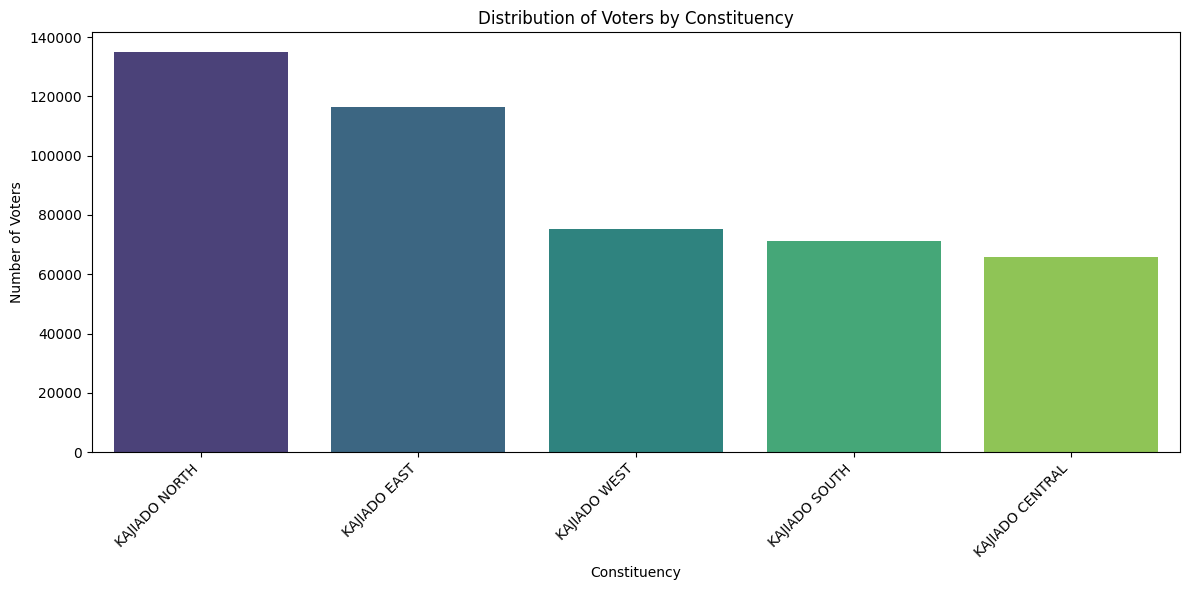

In [25]:
constituency_counts = df['constituency'].value_counts()
constituency_percentages = df['constituency'].value_counts(normalize=True) * 100

print('\n'+'='*70)
print('Distribution of Voters by Constituency:')
print('='*70)
display(constituency_counts)
print('\n'+'='*70)
print('Percentage Distribution of Voters by Constituency:')
print('='*70)
display(constituency_percentages)

plt.figure(figsize=(12, 6))
sns.barplot(x=constituency_counts.index, y=constituency_counts.values, palette='viridis')
plt.title('Distribution of Voters by Constituency')
plt.xlabel('Constituency')
plt.ylabel('Number of Voters')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [26]:
# @title step_artifacts
num_fig = "4" # @param {type:"string"}
step = 'DataExploration'  # @param ["DataLoading", "DataExploration", "DataCleaning", "DataWrangling", "DataVisualization", "DataSplitting", "ModelDevelopment", "ModelOptimization", "ModelEvaluation", "Summary"] {type:"string"}
# upload_plt_to_gcs(num_fig, step, fig) # Assuming fig is defined from the previous plot

### **Average Voter Age by Constituency**



Average Voter Age by Constituency:


,age
constituency,
KAJIADO SOUTH,45.483782
KAJIADO WEST,44.803493
KAJIADO CENTRAL,44.122738
KAJIADO NORTH,44.000489
KAJIADO EAST,42.594579


/tmp/ipykernel_8548/4092477885.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=average_age_by_constituency.index, y=average_age_by_constituency.values, palette='viridis')


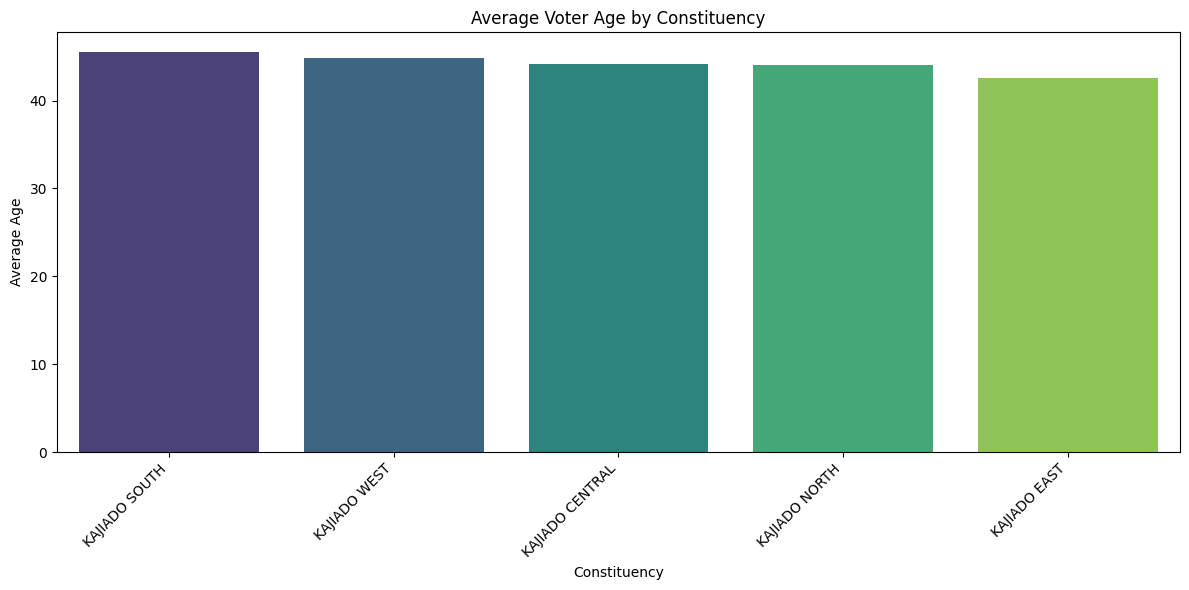

In [27]:
average_age_by_constituency = df.groupby('constituency')['age'].mean().sort_values(ascending=False)

print('\n'+'='*70)
print('Average Voter Age by Constituency:')
print('='*70)
display(average_age_by_constituency)

plt.figure(figsize=(12, 6))
sns.barplot(x=average_age_by_constituency.index, y=average_age_by_constituency.values, palette='viridis')
plt.title('Average Voter Age by Constituency')
plt.xlabel('Constituency')
plt.ylabel('Average Age')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [28]:
# @title step_artifacts
num_fig = "8" # @param {type:"string"}
step = 'DataExploration'  # @param ["DataLoading", "DataExploration", "DataCleaning", "DataWrangling", "DataVisualization", "DataSplitting", "ModelDevelopment", "ModelOptimization", "ModelEvaluation", "Summary"] {type:"string"}
# upload_plt_to_gcs(num_fig, step, fig) # Assuming fig is defined from the previous plot

### Summary Statistics of the DataFrame

Let's display the summary statistics for the entire DataFrame, including both numerical and categorical columns, to get a better understanding of the data distribution.

In [29]:
print('\n'+'='*70)
print('Summary Statistics:')
print('='*70)
display(df.describe(include='all'))


Summary Statistics:


,county,constituency,caw,polling_center,polling_station,pstream,date_of_birth,fname,mname,sname,sex,id_passport_no,birth_year,age
count,463273,463273,463273,463273,463273,463273.000000,463273,463272,348325,463272,463273,463273,463273.000000,463273.000000
unique,1,5,25,442,442,NaN,NaN,95323,57362,72500,2,462977,NaN,NaN
top,KAJIADO,KAJIADO NORTH,KITENGELA,DR.LIKIMANI PRI.SCHOOL,DR.LIKIMANI PRI.SCHOOL,NaN,NaN,JOHN,ENE,MWANGI,Male,24093387,NaN,NaN
freq,463273,134880,38746,30212,30212,NaN,NaN,7284,12980,6133,243125,4,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,4.804353,1982-04-10 11:49:16.857835456,NaN,NaN,NaN,NaN,NaN,1981.977370,44.022630
min,NaN,NaN,NaN,NaN,NaN,1.000000,1850-01-01 00:00:00,NaN,NaN,NaN,NaN,NaN,1850.000000,22.000000
25%,NaN,NaN,NaN,NaN,NaN,1.000000,1974-01-01 00:00:00,NaN,NaN,NaN,NaN,NaN,1974.000000,34.000000
50%,NaN,NaN,NaN,NaN,NaN,2.000000,1985-09-02 00:00:00,NaN,NaN,NaN,NaN,NaN,1985.000000,41.000000
75%,NaN,NaN,NaN,NaN,NaN,5.000000,1992-07-01 00:00:00,NaN,NaN,NaN,NaN,NaN,1992.000000,52.000000
max,NaN,NaN,NaN,NaN,NaN,44.000000,2004-01-16 00:00:00,NaN,NaN,NaN,NaN,NaN,2004.000000,176.000000


In [30]:
# Grouping of data by constituency and count to show the entries by distribution.
print('\n'+'='*70)
print('Entries per Constituency:')
print('='*70)
constituency_counts = df['constituency'].value_counts()
display(constituency_counts)


Entries per Constituency:


,count
constituency,
KAJIADO NORTH,134880
KAJIADO EAST,116336
KAJIADO WEST,75173
KAJIADO SOUTH,71061
KAJIADO CENTRAL,65823


## **4.) Handling Missing Values**

In [31]:
# Identify missing values

print('\n'+'='*70)
print('Missing Values:')
print('='*70)
display(df.isnull().sum())


Missing Values:


,0
county,0
constituency,0
caw,0
polling_center,0
polling_station,0
pstream,0
date_of_birth,0
fname,1
mname,114948
sname,1


### **Handle Missing Values in 'mname' columns.**

The `mname` column has a significant number of missing values. Since it's a middle name, we'll fill the `NaN` values with an empty string (`''`) to ensure consistency and avoid issues with operations that expect string types.

In [32]:
# Fill missing values in 'mname' with an empty string
df['mname'] = df['mname'].fillna('')

# Verify that there are no more missing values in 'mname'
print('\n'+'='*70)
print('Missing Values After Imputation:')
print('='*70)
display(df.isnull().sum())


Missing Values After Imputation:


,0
county,0
constituency,0
caw,0
polling_center,0
polling_station,0
pstream,0
date_of_birth,0
fname,1
mname,0
sname,1


### Handle Missing Values in 'fname' and 'sname' Columns

Since `fname` and `sname` each have only one missing value, we will drop the corresponding rows. This is a common practice when the number of missing values is very small and they are in critical identifier columns.

In [33]:
# Drop rows where 'fname' or 'sname' are missing
df.dropna(subset=['fname', 'sname'], inplace=True)

# Verify that there are no more missing values in 'fname' and 'sname'
print('\n'+'='*70)
print('Missing Values After Dropping Rows:')
print('='*70)
display(df.isnull().sum())


Missing Values After Dropping Rows:


,0
county,0
constituency,0
caw,0
polling_center,0
polling_station,0
pstream,0
date_of_birth,0
fname,0
mname,0
sname,0


### Final Verification of Missing Values


In [34]:
print('\n'+'='*70)
print('Final Missing Values Check:')
print('='*70)
display(df.isnull().sum())


Final Missing Values Check:


,0
county,0
constituency,0
caw,0
polling_center,0
polling_station,0
pstream,0
date_of_birth,0
fname,0
mname,0
sname,0


### Export Cleaned DataFrame to CSV


In [35]:
# Define the output file path
output_file_path = 'cleaned_034data.csv'

# Export the DataFrame to CSV without the index
df.to_csv(output_file_path, index=False)

print(f"Cleaned DataFrame successfully exported to '{output_file_path}'")

Cleaned DataFrame successfully exported to 'cleaned_034data.csv'


## **5.) Handling Duplicates**

### **Checking for Duplicate Entries**

In [36]:
# Count for duplicate rows and

duplicate_rows = df.duplicated().sum()

print('\n'+'='*70)
print(f'Number of duplicate rows found: {duplicate_rows}')
print('='*70)

if duplicate_rows > 0:
    print('\n'+'='*70)
    print('Duplicate Rows (sorted for side-by-side comparison):')
    print('='*70)
    # Get all duplicate rows (keeping all occurrences)
    all_duplicates = df[df.duplicated(keep=False)]
    # Sort by all columns to show identical rows side-by-side
    display(all_duplicates.sort_values(by=list(df.columns)))
else:
    print('\n'+'='*70)
    print('No duplicate rows found.')
    print('='*70)


Number of duplicate rows found: 30

Duplicate Rows (sorted for side-by-side comparison):


,county,constituency,caw,polling_center,polling_station,pstream,date_of_birth,fname,mname,sname,sex,id_passport_no,birth_year,age
199012,KAJIADO,KAJIADO CENTRAL,DALALEKUTUK,ISILALE PRIMARY SCHOOL,ISILALE PRIMARY SCHOOL,1,1996-06-15,ANN,SAAYION,TIMA,Female,33090455,1996,30
373522,KAJIADO,KAJIADO CENTRAL,DALALEKUTUK,ISILALE PRIMARY SCHOOL,ISILALE PRIMARY SCHOOL,1,1996-06-15,ANN,SAAYION,TIMA,Female,33090455,1996,30
29786,KAJIADO,KAJIADO CENTRAL,MATAPATO NORTH,EMASHINI PRIMARY SCHOOL,EMASHINI PRIMARY SCHOOL,1,1962-01-01,SHININI,MAMADI,NEGEJU,Female,6108837,1962,64
333759,KAJIADO,KAJIADO CENTRAL,MATAPATO NORTH,EMASHINI PRIMARY SCHOOL,EMASHINI PRIMARY SCHOOL,1,1962-01-01,SHININI,MAMADI,NEGEJU,Female,6108837,1962,64
282816,KAJIADO,KAJIADO CENTRAL,MATAPATO NORTH,ILIMISIGIYO CENTER,ILIMISIGIYO CENTER,1,1989-01-01,MAREN SENEI,,LENGOTONYE,Female,26942513,1989,37
424167,KAJIADO,KAJIADO CENTRAL,MATAPATO NORTH,ILIMISIGIYO CENTER,ILIMISIGIYO CENTER,1,1989-01-01,MAREN SENEI,,LENGOTONYE,Female,26942513,1989,37
310049,KAJIADO,KAJIADO CENTRAL,MATAPATO NORTH,NGATATAEK PRIMARY SCHOOL,NGATATAEK PRIMARY SCHOOL,1,1972-01-01,KITAINEN,ENE,SAKITA,Female,11126097,1972,54
374824,KAJIADO,KAJIADO CENTRAL,MATAPATO NORTH,NGATATAEK PRIMARY SCHOOL,NGATATAEK PRIMARY SCHOOL,1,1972-01-01,KITAINEN,ENE,SAKITA,Female,11126097,1972,54
35174,KAJIADO,KAJIADO CENTRAL,MATAPATO SOUTH,ELUANATA PRIMARY SCHOOL,ELUANATA PRIMARY SCHOOL,1,1985-01-01,NEMARINTA,,KIRINGAI,Female,24371013,1985,41
114220,KAJIADO,KAJIADO CENTRAL,MATAPATO SOUTH,ELUANATA PRIMARY SCHOOL,ELUANATA PRIMARY SCHOOL,1,1985-01-01,NEMARINTA,,KIRINGAI,Female,24371013,1985,41
